In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt

In [2]:
data_dir = Path("../data/raw")
csv_files = sorted(data_dir.glob("*.csv"))

csv_files

[WindowsPath('../data/raw/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2022_1.csv'),
 WindowsPath('../data/raw/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2022_2.csv'),
 WindowsPath('../data/raw/On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2022_3.csv')]

In [3]:
cols = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "CRSDepTime",
    "DepDelay",
    "Cancelled"
]

In [4]:
dfs = []

for file in csv_files:
    df_part = pd.read_csv(file, usecols=cols)
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)

df.shape

(1598468, 8)

In [5]:
df.head()

,Month,DayOfWeek,Reporting_Airline,Origin,Dest,CRSDepTime,DepDelay,Cancelled
0,1,5,YX,CMH,DCA,1224,-3.0,0.0
1,1,6,YX,CMH,DCA,1224,-10.0,0.0
2,1,7,YX,CMH,DCA,1224,-6.0,0.0
3,1,1,YX,CMH,DCA,1224,-7.0,0.0
4,1,2,YX,CMH,DCA,1224,-6.0,0.0


In [6]:
df = df[df["Cancelled"] == 0].copy()

df = df.dropna(subset=[
    "DepDelay",
    "CRSDepTime",
    "Reporting_Airline",
    "Origin",
    "Dest"
])

df.shape

(1534734, 8)

In [7]:
df = df.sample(n=200_000, random_state=42)
df.shape

(200000, 8)

In [8]:
df["delay_flag"] = (df["DepDelay"] > 15).astype(int)

df[["DepDelay", "delay_flag"]].head(10)

,DepDelay,delay_flag
1520653,-7.0,0
344435,-5.0,0
399849,-8.0,0
210583,-15.0,0
1241754,152.0,1
1512894,-1.0,0
324523,-6.0,0
973753,0.0,0
961953,-6.0,0
665439,-4.0,0


In [9]:
df["CRSDepTime"] = df["CRSDepTime"].astype(int)
df["dep_hour"] = df["CRSDepTime"] // 100

df[["CRSDepTime", "dep_hour"]].head(10)

,CRSDepTime,dep_hour
1520653,1316,13
344435,1415,14
399849,1329,13
210583,1110,11
1241754,2012,20
1512894,1045,10
324523,1955,19
973753,1115,11
961953,1722,17
665439,600,6


In [10]:
features = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Origin",
    "Dest",
    "dep_hour"
]

X = df[features]
y = df["delay_flag"]

X.head()

,Month,DayOfWeek,Reporting_Airline,Origin,Dest,dep_hour
1520653,3,7,AA,DFW,ABQ,13
344435,1,2,WN,SAN,PHX,14
399849,1,5,YX,JFK,BWI,13
210583,1,4,HA,LAX,KOA,11
1241754,3,4,F9,DEN,ORD,20


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
numeric_features = ["Month", "DayOfWeek", "dep_hour"]
categorical_features = ["Reporting_Airline", "Origin", "Dest"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=50,
        max_depth = 12,
        min_samples_leaf=5,
        random_state=42,
        class_weight= "balanced",
        n_jobs=-1
    ))
])

In [13]:
model.fit(X_train, y_train)

KeyboardInterrupt: 

In [ ]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     32129
           1       0.00      0.00      0.00      7871

    accuracy                           0.80     40000
   macro avg       0.40      0.50      0.45     40000
weighted avg       0.65      0.80      0.72     40000



c:\Users\rufus\flight-delay-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rufus\flight-delay-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rufus\flight-delay-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()}

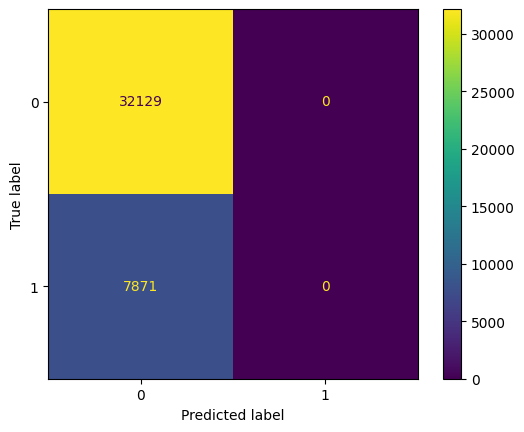

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.show()

In [ ]:
df["delay_flag"].value_counts(normalize=True)

delay_flag
0    0.803215
1    0.196785
Name: proportion, dtype: float64